In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [3]:
def plot_image(image_1, image_2, title_1="Original", title_2="Modified Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1)
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2)
    plt.title(title_2)
    plt.show()


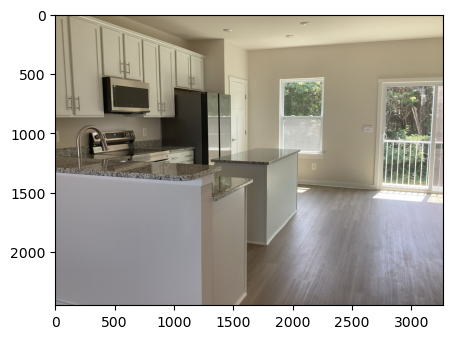

In [4]:
image = Image.open("IMG_0259.jpg")
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.show()

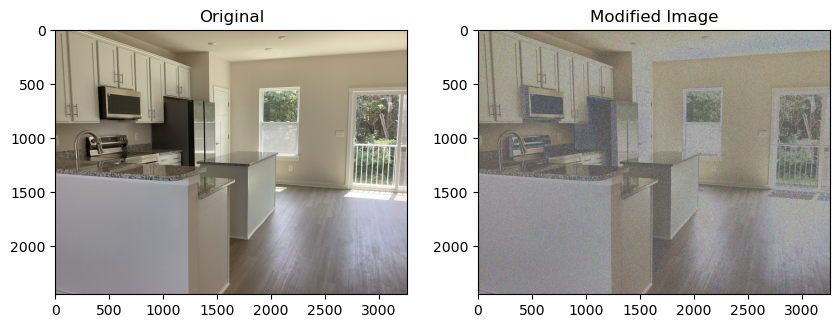

In [5]:
row, col = image.size
noise = np.random.normal(0,50,(col, row,3)).astype(np.uint8)
noisy_image = image + noise
plot_image(image, noisy_image)

When adding noise to an image sometimes the value might be greater than 255, in this case 256, is subtracted from the value to wrap the number around keeping it between 0 and 255. For example, consider an image with an RGB value of 137 and we add noise with an RGB value of 215 to get an RGB value of 352. We then subtract 256, the total number of possible values between 0 and 255, to get a number between 0 and 255.

In [6]:
from PIL import ImageFilter


In [7]:
# Create a kernel 5x5 filter
kernel = np.ones((5,5))/25;
print(kernel.shape)
image_filter = ImageFilter.Kernel((5,5), kernel.flatten())

(5, 5)


In [8]:
image_filtered = Image.fromarray(noisy_image).filter(image_filter)

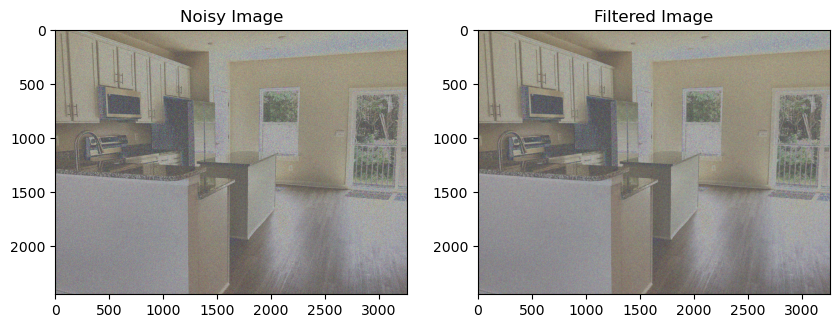

In [9]:
plot_image(noisy_image, image_filtered, title_1="Noisy Image", title_2="Filtered Image")


### Gaussian Blur

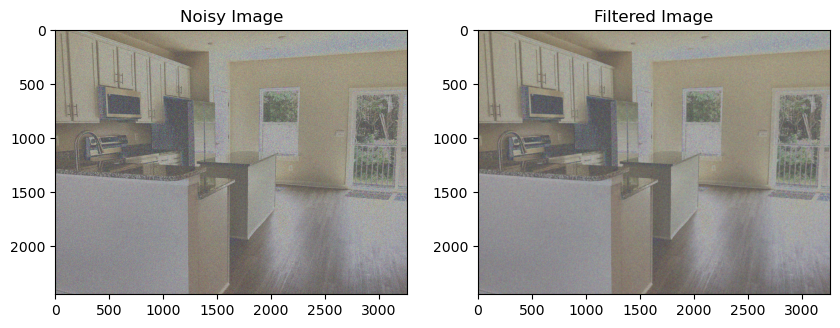

In [10]:
# Filter image using GaussianBlur default blur kernel radius 2
image_filtered = Image.fromarray(noisy_image).filter(ImageFilter.GaussianBlur)
plot_image(noisy_image, image_filtered, title_1="Noisy Image", title_2="Filtered Image")


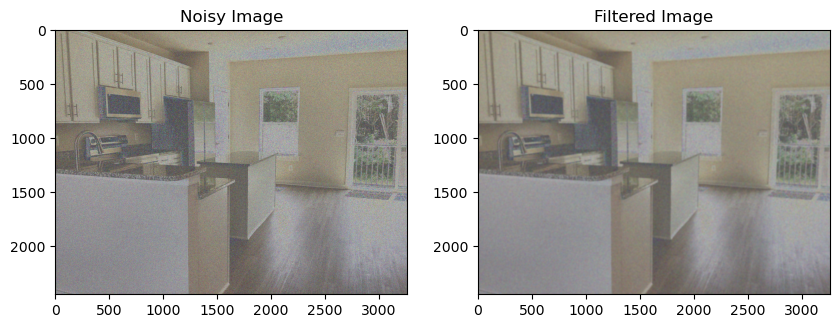

In [11]:
# Filter image using GaussianBlur blur kernel radius 5
image_filtered = Image.fromarray(noisy_image).filter(ImageFilter.GaussianBlur(5))
plot_image(noisy_image, image_filtered, title_1="Noisy Image", title_2="Filtered Image")


### Image Sharpening

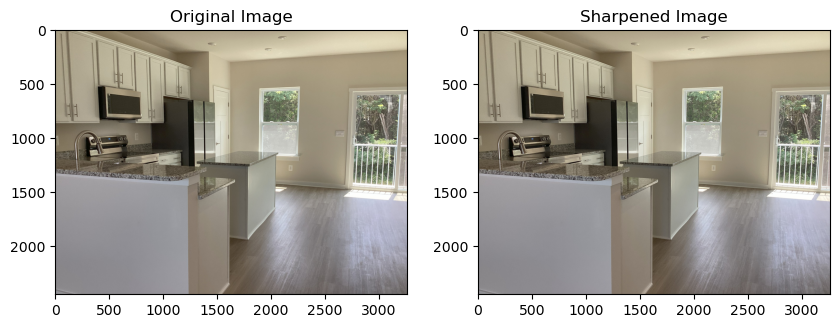

In [12]:
# Sharpened Image using predefined image filter 
sharpened = image.filter(ImageFilter.SHARPEN)
plot_image(image, sharpened, title_1="Original Image", title_2="Sharpened Image")


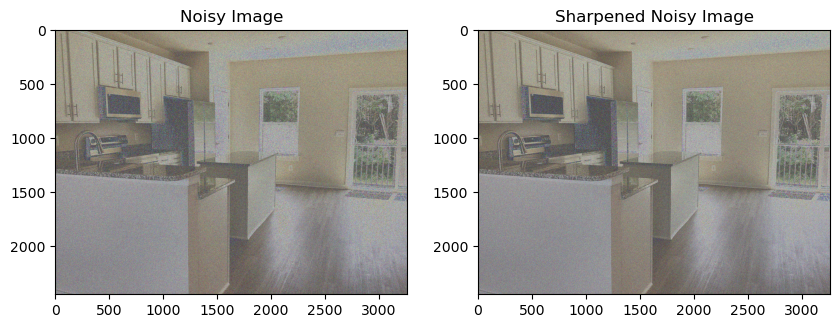

In [13]:
sharpened = Image.fromarray(noisy_image).filter(ImageFilter.SHARPEN)
plot_image(noisy_image, sharpened, title_1="Noisy Image", title_2="Sharpened Noisy Image")

### Edges 

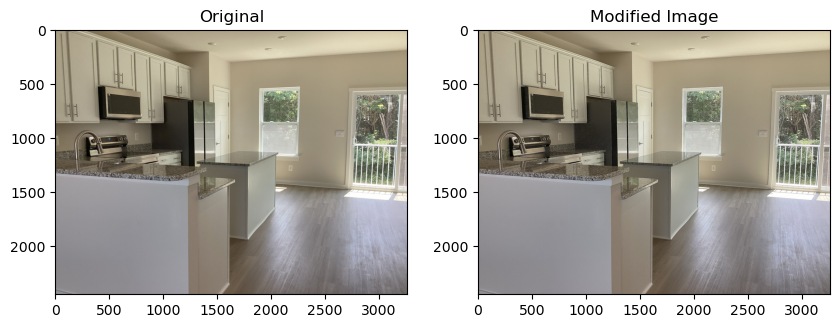

In [14]:
edge_enhance = image.filter(ImageFilter.EDGE_ENHANCE)
plot_image(image, edge_enhance)

### Median Filter

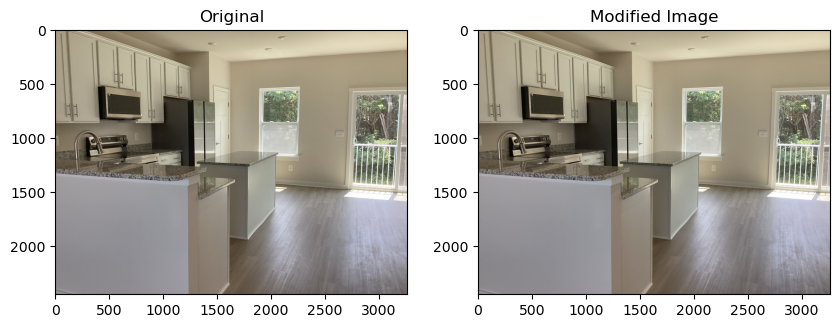

In [15]:
med_enhance = image.filter(ImageFilter.MedianFilter)
plot_image(image, med_enhance)